<a href="https://colab.research.google.com/github/314sirius/Graphs/blob/main/shortest_path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import heapq

def dijkstra_v6(graph, start_node):
    """
    Implements Dijkstra's algorithm using a priority queue.
    """
    # Initialize distances. Key=Node, Value=Min distance from start_node.
    # We use infinity for all nodes except the start.
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0

    # Priority Queue store pairs: (current_distance, node)
    priority_queue = [(0, start_node)]

    # Optional: to trace the previous nodes in the shortest path
    predecessors = {node: None for node in graph}

    # Tracking visited nodes to avoid processing the same node multiple times
    # when a priority queue might contain multiple entries for the same node.
    visited_final = set()

    while priority_queue:
        # 1. 'JUMP' to the closest available node from the unvisited set
        # This is the "Greedy" choice.
        current_distance, current_node = heapq.heappop(priority_queue)

        # Performance optimization: if we found a shorter path to current_node already
        if current_node in visited_final:
            continue

        # 2. MARK current_node as finalized (visited)
        visited_final.add(current_node)

        # 3. 'RELAXATION': Check all neighbors of the current_node
        for neighbor, weight in graph[current_node].items():
            new_distance = current_distance + weight

            # 4. UPDATE (Relax): If we found a shorter path to the neighbor
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                predecessors[neighbor] = current_node
                # Push the node to priority queue with new priority
                heapq.heappush(priority_queue, (new_distance, neighbor))

    return distances, predecessors

# --- Graph Definition from Image image_1.png ---
# Using nested dictionary as an Adjacency List. Key=Node, Value={Neighbor: Weight}
graph = {
    '1': {'5': 13, '6': 9, '7': 6, '8': 3},
    '2': {'3': 6, '6': 7, '8': 8},
    '3': {'2': 6, '4': 9, '6': 2},
    '4': {'3': 9, '5': 18, '6': 8},
    '5': {'1': 13, '4': 18, '6': 7, '7': 4},
    '6': {'1': 9, '2': 7, '3': 2, '4': 8, '5': 7, '8': 2},
    '7': {'1': 6, '5': 4, '8': 5},
    '8': {'1': 3, '2': 8, '6': 2, '7': 5}
}

# --- Execute from Node 6 ---
start = '6'
distances_map, predecessors_map = dijkstra_v6(graph, start)

# --- Format and Print Results (The 314sirius way) ---
print(f"--- Dijkstra's Implementation. Starting from Node: {start} ---")
print("| Node | Shortest Distance | Final Shortest Path to Source |")
print("|------|-------------------|-------------------------------|")

# Function to reconstruct the path
def reconstruct_path(preds_map, node, start_node):
    path = []
    curr = node
    while curr:
        path.append(curr)
        curr = preds_map[curr]
    return " -> ".join(reversed(path))

# Sorting nodes numerically for clean output
sorted_nodes = sorted(graph.keys(), key=int)

for node in sorted_nodes:
    dist = distances_map[node]
    #prev = predecessors_map[node] or 'Source' if node == start else 'None'
    path_str = reconstruct_path(predecessors_map, node, start)
    print(f"| {node:^4} | {dist:^17} | {path_str:<29} |")

print("-------------------------------------------------------------------------------")

--- Dijkstra's Implementation. Starting from Node: 6 ---
| Node | Shortest Distance | Final Shortest Path to Source |
|------|-------------------|-------------------------------|
|  1   |         5         | 6 -> 8 -> 1                   |
|  2   |         7         | 6 -> 2                        |
|  3   |         2         | 6 -> 3                        |
|  4   |         8         | 6 -> 4                        |
|  5   |         7         | 6 -> 5                        |
|  6   |         0         | 6                             |
|  7   |         7         | 6 -> 8 -> 7                   |
|  8   |         2         | 6 -> 8                        |
-------------------------------------------------------------------------------


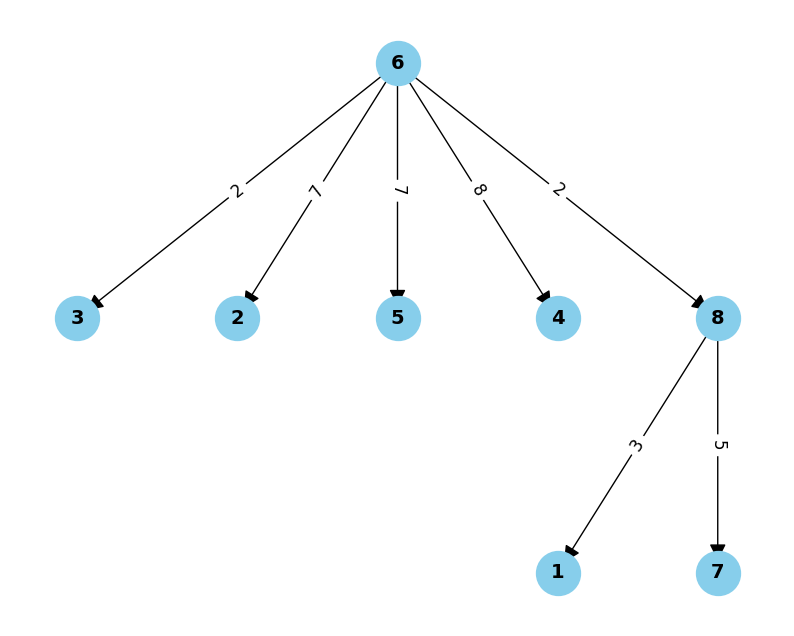

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the NetworkX graph (copying the SPT structure from the previous step)
# We create a DiGraph (Directed Graph)
SPT = nx.DiGraph()

# Add edges based on the Shortest Path Tree (Root: 6) from the table
edges = [
    ('6', '3', {'weight': 2}),
    ('6', '2', {'weight': 7}),
    ('6', '5', {'weight': 7}),
    ('6', '4', {'weight': 8}),
    ('6', '8', {'weight': 2}),
    ('8', '1', {'weight': 3}), # Path 6->8->1
    ('8', '7', {'weight': 5})  # Path 6->8->7
]
SPT.add_edges_from(edges)

# 2. Visualization
plt.figure(figsize=(10, 8))

# IMPORTANT: Using pydot_layout for hierarchical arrangement
# We specify 'dot' (standard Graphviz layout for trees)
# NOTE: If pydot is not installed, this code will throw an error.
try:
    from networkx.drawing.nx_pydot import pydot_layout
    pos = pydot_layout(SPT, prog='dot') # 'dot' makes a top-down structure
except ImportError:
    print("Error: pydot is not installed. Using shell_layout as a fallback (it is not hierarchical).")
    pos = nx.shell_layout(SPT)

# Draw nodes and edges
nx.draw_networkx_nodes(SPT, pos, node_size=1000, node_color='skyblue')
nx.draw_networkx_edges(SPT, pos, edgelist=SPT.edges(), edge_color='black', arrows=True, arrowsize=25)
nx.draw_networkx_labels(SPT, pos, font_size=14, font_family='sans-serif', font_weight='bold')


# Draw edge weights (to confirm it's an SPT)
edge_labels = nx.get_edge_attributes(SPT, 'weight')
nx.draw_networkx_edge_labels(SPT, pos, edge_labels=edge_labels, font_size=12)

#plt.title("Dijkstra Shortest Path Tree (Root: 6) - Hierarchical Layout")
plt.axis('off') # Turn off axes

plt.savefig("dijkstra.pdf", format="pdf", bbox_inches='tight')

plt.show()